# Assignment 1: Data project


**Table of contents**<a id='toc0_'></a>
- 1. [Inequality in Denmark](#toc1_)
  - 1.1. [The Gini coefficient and the top 10 percent share](#toc1_1_)
    - 1.1.1 [Gini coefficient for Denmark over time](#toc1_1_1_)
    - 1.1.2 [Define the share of total income going to the richest 10 percent](#toc1_1_2_)
    - 1.1.3 [Compare Gini coefficient and top 10%](#toc1_1_3_)
  - 1.2. [Prediction](#toc1_2_)
    - 1.2.1 [Solve minimization problem](#toc1_2_1_)
    - 1.2.2 [Compare with np.polyfit](#toc1_2_2_)
    - 1.2.3 [Prediction of the Gini coefficient in 2030 and 2040](#toc1_2_3_)
  - 1.3. [Municipalities](#toc1_3_)
    - 1.3.1 [Correlation between the Gini coefficient and the top 10 percent share across municipalities](#toc1_3_1_)
    - 1.3.2 [Most and least unequal municipalities in 2024](#toc1_3_2_)
    - 1.3.3 [Changes in the Gini coefficient over time](#toc1_3_3_)
  - 1.4. [Extension](#toc1_4_)
- 2. [Simulating the income distribution](#toc0_)
  - 2.1. [The model](#toc2_1_)
  - 2.2. [Simulate the income distribution](#toc2_2_)
    - 2.2.1 [Control checks](#toc_2_3_1)
    - 2.2.2 [Mean and selected percentiles of income over the life cycle](#toc_2_3_2)
    - 2.2.3 [Histograms of the income distribution at different ages](#toc_2_3_2)
  - 2.3. [Compute the Gini coefficient](#toc2_3_)
    - 2.3.1 [Gini coefficient and Lorenz curve for the full simulated sample](#toc_2_3_1)
    - 2.3.2 [Compute the Gini coefficient for all ages in the model](#toc_2_3_2)
  - 2.4. [What drives inequality?](#toc2_4_)
  - 2.5. [Extension: more risk](#toc2_5_)

## 1. <a id='toc1_'></a>[Inequality in Denmark](#toc1_)

### 1.1. <a id='toc1_1_'></a>[The Gini coefficient and the top 10 percent share](#toc0_)

#### 1.1.1. <a id='toc1_1_'></a>[Gini coefficient for Denmark over time](#toc0_)

First, we import relevant packages and data from dst:

In [1]:
#%pip install git+https://github.com/alemartinello/dstapi

import numpy as np
import pandas as pd

# APIs
#from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

from scipy.optimize import minimize

from scipy.stats import linregress

# Load data from dst:
from dstapi import DstApi

We load the data on Gini coefficient:

In [2]:
IFOR41 = DstApi('IFOR41') 

Information about the variables:

In [3]:
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


We see that All Denmark = 000 and ULLIG=70. We use this to extract the relevant data:

In [4]:
# Set the parameters for the data we want to download
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},       # Gini coefficient
        {'code': 'KOMMUNEDK', 'values': ['000']},  # All Denmark
        {'code': 'Tid', 'values': ['*']}           # all years
    ]
}

# Download the data into a dataFrame
Gini = IFOR41.get_data(params=params)

# Set the correct data types and sort the observations by year
Gini['TID'] = Gini['TID'].astype(int)
Gini['INDHOLD'] = Gini['INDHOLD'].astype(float)
Gini = Gini.set_index('TID').sort_index()

# Display
display(Gini.head(5))

,ULLIG,KOMMUNEDK,INDHOLD
TID,,,
1987,Gini coefficient,All Denmark,22.07
1988,Gini coefficient,All Denmark,22.06
1989,Gini coefficient,All Denmark,21.93
1990,Gini coefficient,All Denmark,22.16
1991,Gini coefficient,All Denmark,21.99


We plot the Gini coefficient from 1987-2024: 

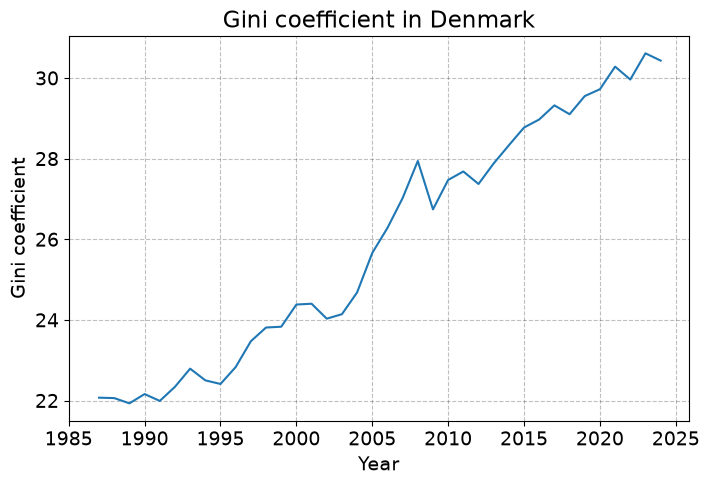

1987: 22.070
2024: 30.430
Increase: 8.360 percentage points


In [5]:
# Plot
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(Gini.index, Gini['INDHOLD'])

ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

ax.set_xticks(list(range(1985, 2025, 5)) + [2025])

plt.show()

# Change in Gini
increase = Gini.loc[2024, 'INDHOLD'] - Gini.loc[1987, 'INDHOLD']
print(f"1987: {Gini.loc[1987, 'INDHOLD']:.3f}")
print(f"2024: {Gini.loc[2024, 'INDHOLD']:.3f}")
print(f"Increase: {increase:.3f} percentage points")   

We see that the Gini coefficient has been rising over the period, from 22% in 1987 to 30% in 2024, corresponding to an increase of 8 percentage points. We see the largest decrease in the Gini coefficient in 2009, following the financial crisis.

#### 1.1.2. <a id='toc1_1_'></a>[Define the share of total income going to the richest 10 percent](#toc0_)

We add data on income across the different decile groups.

In [6]:
# Load data
IFOR32 = DstApi('IFOR32')

# Check the variables and their values
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


We extract the relevant variables:

In [7]:
# Set download parameters
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},       # All 10 income deciles
        {'code': 'KOMMUNEDK', 'values': ['000']},    # All Denmark
        {'code': 'Tid', 'values': ['*']}             # All years
    ]
}

# Download the data
Deciles = IFOR32.get_data(params=params)

# Set types
Deciles['TID'] = Deciles['TID'].astype(int)
Deciles['INDHOLD'] = Deciles['INDHOLD'].astype(float)

# Sort data
order = ['First decil', 'Second decil', 'Third decil', 'Fourth decil', 'Fifth decil', 'Sixth decil', 'Seventh decil', 'Eigth decil', 'Ninth decil', 'Tenth decil']
Deciles['DECILGEN'] = pd.Categorical(Deciles['DECILGEN'], categories=order, ordered=True)
Deciles = Deciles.sort_values(['TID', 'DECILGEN'])

# Display 
display(Deciles.head(5))

,DECILGEN,KOMMUNEDK,TID,INDHOLD
260,First decil,All Denmark,1987,31418.0
261,Second decil,All Denmark,1987,59014.0
262,Third decil,All Denmark,1987,68786.0
263,Fourth decil,All Denmark,1987,77577.0
264,Fifth decil,All Denmark,1987,85361.0


We calculate the share of total income going to the richest 10 percent (top 10%) by dividing average income of tenth decile by total income of all deciles:

In [8]:
#for each year take the tenth decil income and divide with total income
Top10 = Deciles.groupby('TID').apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum())*100

display(Top10.head())

TID
1987    18.454866
1988    18.428870
1989    18.495170
1990    18.641480
1991    18.668346
dtype: float64

#### 1.1.3. <a id='toc1_1_'></a>[Compare Gini coefficient and top 10%](#toc0_)

We plot Gini coefficient and top 10% in same diagram:

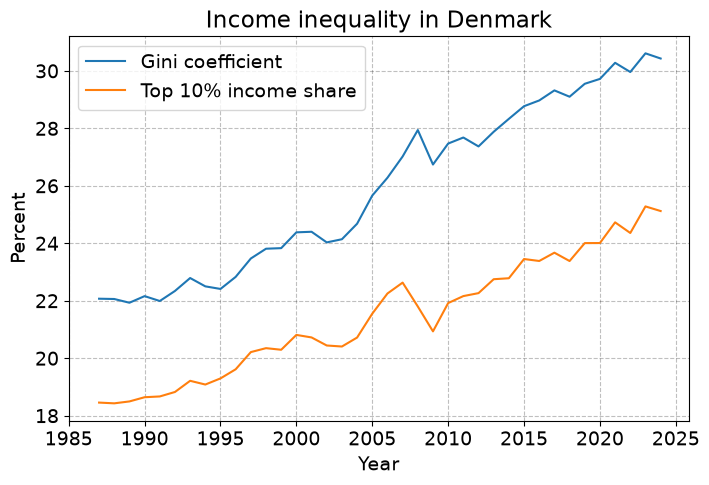

In [9]:
# Combine the Gini coefficient and top 10% income share by year
df = pd.concat([Gini['INDHOLD'].rename('Gini'), Top10.rename('Top 10%')], axis=1)

# Plot both measures over time
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(df.index, df['Gini'], label='Gini coefficient')
ax.plot(df.index, df['Top 10%'], label='Top 10% income share')

ax.set_title('Income inequality in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Percent')
ax.legend()
#ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=12, handlelength=1.5)
ax.set_xticks(list(range(1985, 2025, 5)) + [2025])

plt.show()

We see that both measures show that inequality has risen over the period, with similar fluctuations over time. Thus, the top 10% income share largely captures the overall changes in inequality over time.

We compute the correlation between the two variables:

In [10]:
corr = Gini['INDHOLD'].corr(Top10)
print(corr)

0.981641545052772


Hence, there is a strong positive correlation between the two variables, suggesting that the two measures are closely aligned.

### 1.2. <a id='toc1_1_'></a>[Prediction](#toc0_)

#### 1.2.1. <a id='toc1_1_'></a>[Solve minimization problem](#toc0_)

We solve the minimization problem using scipy.optimize.minimize:

In [11]:
# t is the number of years since 1987
t = Gini.index - 1987
y = Gini['INDHOLD']

# Define the sum of squared errors for a polynomial of degree p
# The function returns the total squared difference between actual and predicted values. This is what we want to minimize
def objective(beta, t, y, p):
    prediction = sum(beta[k] * t**k for k in range(p + 1))
    return np.sum((y - prediction)**2)   

# p = 1: linear trend 
linear = minimize(objective, np.zeros(2), args=(t, y, 1))

# p = 2: quadratic trend
quadratic = minimize(objective, np.zeros(3), args=(t, y, 2))

print("Linear coefficients:", linear.x)
print("Quadratic coefficients:", quadratic.x)

Linear coefficients: [21.04275355  0.26354959]
Quadratic coefficients: [2.13041867e+01 2.19975902e-01 1.17767450e-03]


#### 1.2.2. <a id='toc1_1_'></a>[Compare with np.polyfit](#toc0_)

We check whether our result is similar to the result obtained using the built-in minimizer.

In [12]:
# Check the linear trend
polyfit_linear = np.polyfit(t, y, 1)

# Check the quadratic trend
polyfit_quadratic = np.polyfit(t, y, 2)

print("Linear:")
print("minimize:", linear.x)
print("polyfit:", polyfit_linear[::-1])

print("Quadratic:")
print("minimize:", quadratic.x)
print("polyfit:", polyfit_quadratic[::-1])

Linear:
minimize: [21.04275355  0.26354959]
polyfit: [21.04275304  0.26354962]
Quadratic:
minimize: [2.13041867e+01 2.19975902e-01 1.17767450e-03]
polyfit: [2.13042004e+01 2.19975061e-01 1.17769085e-03]


We see that the results are almost identical. 

#### 1.2.3. <a id='toc1_1_'></a>[Prediction of the Gini coefficient in 2030 and 2040](#toc0_)

We predict the Gini coefficient in 2030 and 2024:

In [13]:
# Prediction years
t_pred = np.array([2030 - 1987, 2040 - 1987])

# Linear predictions
linear_pred = linear.x[0] + linear.x[1] * t_pred

# Quadratic predictions
quadratic_pred = quadratic.x[0] + quadratic.x[1] * t_pred + quadratic.x[2] * t_pred**2

print("Linear predictions:", linear_pred)
print("Quadratic predictions:", quadratic_pred)

Linear predictions: [32.37538611 35.01088205]
Quadratic predictions: [32.94067063 36.27099718]


We plot the predicted values:

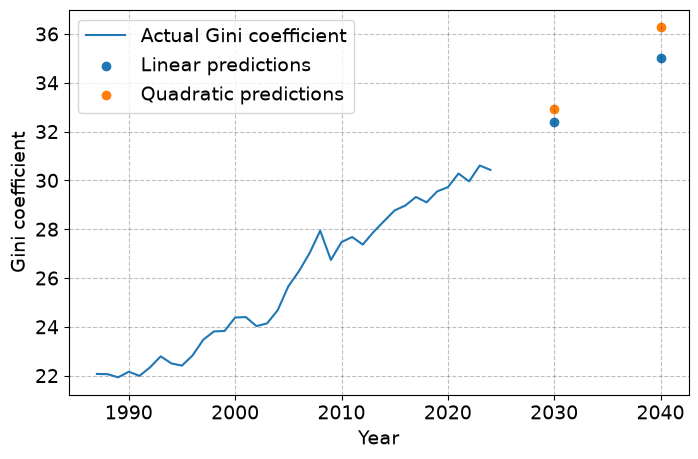

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(Gini.index, y, label='Actual Gini coefficient')

plt.scatter([2030, 2040], linear_pred, label='Linear predictions')
plt.scatter([2030, 2040], quadratic_pred, label='Quadratic predictions')

plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.legend()
plt.show()

We find that the quadratic trend predicts a stronger increase in the Gini coefficient over time. However, it is not clear which specification provides the more reliable prediction. Since the Gini coefficient is influenced by many factors, this simple trend model is unlikely to accurately predict future inequality. Past trends may not necessarily be good predictors of future developments.

### 1.3. <a id='toc1_1_'></a>[Municipalities](#toc0_)

#### 1.3.1. <a id='toc1_1_'></a>[Correlation between the Gini coefficient and the top 10 percent share across municipalities](#toc0_)

We import the data again now on the municipality level:

In [15]:
# Set the parameters for the data we want to download
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['1987', '2024']}
    ]
}

# Download the data into a pandas DataFrame
Gini_municipal = IFOR41.get_data(params=params)
Gini_municipal = Gini_municipal[Gini_municipal['KOMMUNEDK'] != 'All Denmark']

# Set the correct data types and sort
Gini_municipal['TID'] = Gini_municipal['TID'].astype(int)
Gini_municipal['INDHOLD'] = Gini_municipal['INDHOLD'].astype(float)

Gini_2024 = Gini_municipal[Gini_municipal['TID'] == 2024][['KOMMUNEDK', 'INDHOLD']]
Gini_1987 = Gini_municipal[Gini_municipal['TID'] == 1987][['KOMMUNEDK', 'INDHOLD']]

# Display
display(Gini_2024.head(5))

,KOMMUNEDK,INDHOLD
100,Copenhagen,34.97
101,Frederiksberg,36.54
102,Ballerup,26.72
103,Brøndby,26.16
104,Dragør,28.86


Likewise for income deciles:

In [16]:
# Set download parameters
params = {
'table': 'IFOR32',
'format': 'BULK',
'lang': 'en',
'variables': [
{'code': 'DECILGEN', 'values': ['*']},       # All 10 income deciles
{'code': 'KOMMUNEDK', 'values': ['*']},      # All municipalities
{'code': 'Tid', 'values': ['1987', '2024']}
]
}

# Download the data
Deciles_municipal = IFOR32.get_data(params=params)
Deciles_municipal = Deciles_municipal[Deciles_municipal['KOMMUNEDK'] != 'All Denmark']

# Set types and sort
Deciles_municipal['TID'] = Deciles_municipal['TID'].astype(int)
Deciles_municipal['INDHOLD'] = Deciles_municipal['INDHOLD'].astype(float)

# Calculate top 10% income share for each municipality and year
Top10_2024 = Deciles_municipal[Deciles_municipal['TID'] == 2024].groupby('KOMMUNEDK', sort=False).apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum() * 100).reset_index(name='Top10')

# Display
display(Top10_2024.head(5))

,KOMMUNEDK,Top10
0,Copenhagen,26.660607
1,Frederiksberg,29.120775
2,Ballerup,21.570696
3,Brøndby,20.506813
4,Dragør,24.101741


We compute the correlation between the Gini coefficient and the top 10 percent share across municipalities:

In [17]:
corr_data = Gini_2024.merge(Top10_2024, on='KOMMUNEDK')
corr = corr_data['INDHOLD'].corr(corr_data['Top10'])
print(corr)

0.9747061399602605


There is a strong positive correlation, very similar to the correlation observed over time.

#### 1.3.2. <a id='toc1_1_'></a>[Most and least unequal municipalities in 2024](#toc0_)

We identify the 10 most and least unequal municipalities using both the Gini coefficient and the top 10% income share to assess whether the two measures give consistent results.

In [18]:
most_unequal = Gini_2024.nlargest(10, 'INDHOLD')
least_unequal = Gini_2024.nsmallest(10, 'INDHOLD').iloc[::-1]

most_unequal_10 = Top10_2024.nlargest(10, 'Top10')
least_unequal_10 = Top10_2024.nsmallest(10, 'Top10').iloc[::-1]

display(least_unequal.head(5))
display(most_unequal.head(5))

,KOMMUNEDK,INDHOLD
176,Odder,24.70
109,Albertslund,24.66
184,Hedensted,24.58
147,Assens,24.46
175,Favrskov,24.41


,KOMMUNEDK,INDHOLD
105,Gentofte,49.04
123,Rudersdal,47.31
163,Vejen,46.32
122,Hørsholm,40.07
112,Lyngby-Taarbæk,39.28


Plot:

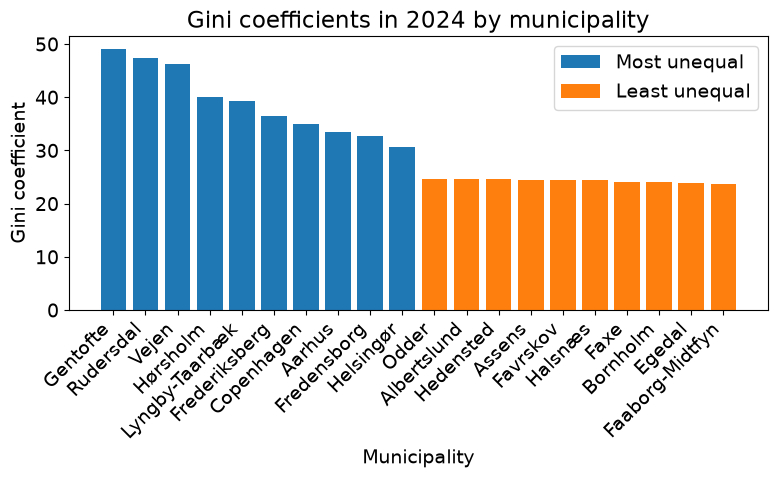

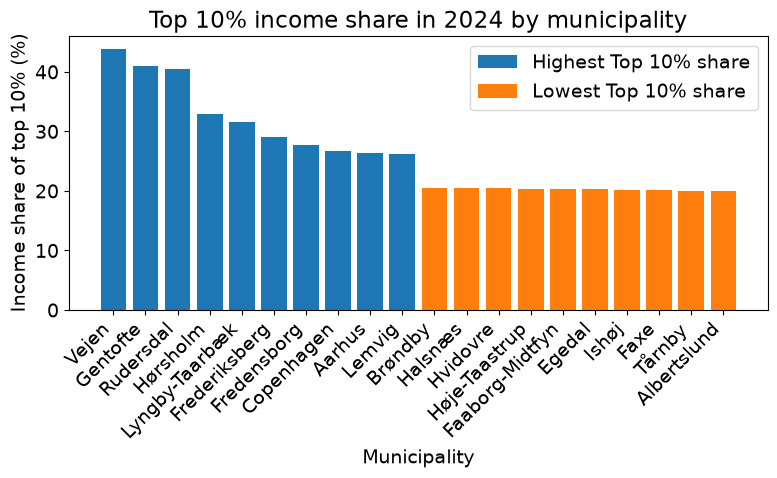

In [19]:
# Gini
plt.figure(figsize=(8,5))
plt.bar(most_unequal['KOMMUNEDK'], most_unequal['INDHOLD'], label='Most unequal')
plt.bar(least_unequal['KOMMUNEDK'], least_unequal['INDHOLD'], label='Least unequal')
plt.ylabel('Gini coefficient')
plt.xlabel('Municipality')
plt.title('Gini coefficients in 2024 by municipality')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Top 10% income share
plt.figure(figsize=(8,5))
plt.bar(most_unequal_10['KOMMUNEDK'], most_unequal_10['Top10'], label='Highest Top 10% share')
plt.bar(least_unequal_10['KOMMUNEDK'], least_unequal_10['Top10'], label='Lowest Top 10% share')
plt.ylabel('Income share of top 10% (%)')
plt.xlabel('Municipality')
plt.title('Top 10% income share in 2024 by municipality')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

We find that using either the top 10% income share or the Gini coefficient gives broadly similar results when identifying the most and least unequal municipalities. Although the ranking changes slightly, the same municipalities generally appear among the most and least unequal. 

We find that many municipalities in Northern Zealand are relatively unequal. Moreover, Vejen and Lemvig are among the most unequal municipalities. Since these are relatively small municipalities, their high inequality may be driven by a small number of individuals with very high incomes. If these individuals were excluded, these municipalities would likely no longer rank among the most unequal.

#### 1.3.3. <a id='toc1_1_'></a>[Changes in the Gini coefficient over time](#toc0_)

We calculate the change in the Gini coeffient between 1987 and 2024:

In [20]:
Gini_change = Gini_2024.merge(Gini_1987, on='KOMMUNEDK', suffixes=('_2024', '_1987'))
Gini_change['change'] = Gini_change['INDHOLD_2024'] - Gini_change['INDHOLD_1987']

display(Gini_change.nsmallest(1, 'change'))
display(Gini_change.nlargest(1, 'change'))

,KOMMUNEDK,INDHOLD_2024,INDHOLD_1987,change
61,Fanø,26.34,25.67,0.67


,KOMMUNEDK,INDHOLD_2024,INDHOLD_1987,change
63,Vejen,46.32,21.2,25.12


Plot:

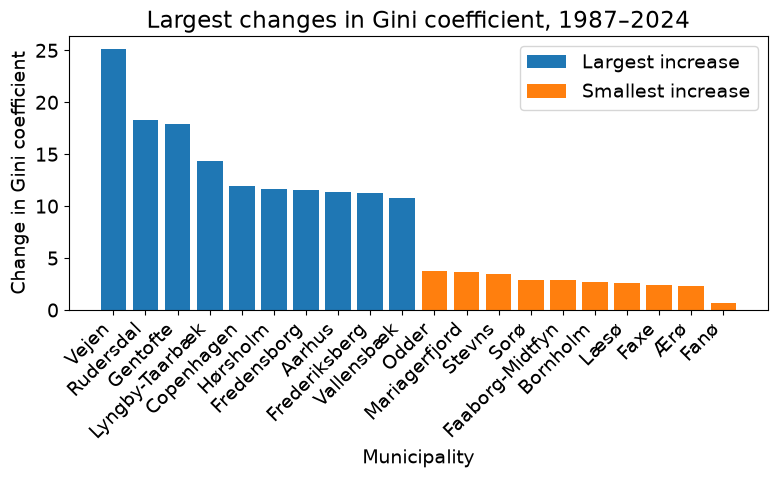

In [21]:
largest_increase = Gini_change.nlargest(10, 'change')
smallest_increase = Gini_change.nsmallest(10, 'change').iloc[::-1]

plt.figure(figsize=(8,5))
plt.bar(largest_increase['KOMMUNEDK'], largest_increase['change'], label='Largest increase')
plt.bar(smallest_increase['KOMMUNEDK'], smallest_increase['change'], label='Smallest increase')

plt.ylabel('Change in Gini coefficient')
plt.xlabel('Municipality')
plt.title('Largest changes in Gini coefficient, 1987–2024')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

Generally, the Gini coefficient has increased across all municipalities from 1987 to 2024.

We see that the Gini coefficient increased particularly sharply in Vejen, by around 25 percentage points. This suggests that the increase may be driven by a small number of individuals with very high incomes, although we cannot determine this from the Gini coefficient alone.

### 1.4. <a id='toc1_1_'></a>[Extension](#toc1_4_)

We examine the income change for the 10% of the population with the lowest incomes (the “bottom 10%”).

In [22]:
# Calculate the bottom 10%:
Bottom10_2024 = Deciles_municipal[Deciles_municipal['TID'] == 2024].groupby('KOMMUNEDK', sort=False).apply(lambda x: x.loc[x['DECILGEN'] == 'First decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum() * 100).reset_index(name='Bund10')
Bottom10_1987 = Deciles_municipal[Deciles_municipal['TID'] == 1987].groupby('KOMMUNEDK', sort=False).apply(lambda x: x.loc[x['DECILGEN'] == 'First decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum() * 100).reset_index(name='Bund10')

# Calculate relative change between 1987 and 2024:
bottom10_change = Bottom10_2024.merge(Bottom10_1987, on='KOMMUNEDK', suffixes=('_2024', '_1987'))
bottom10_change['change'] = bottom10_change['Bund10_2024'] - bottom10_change['Bund10_1987']

We use a scatter plot to depict the correlation:

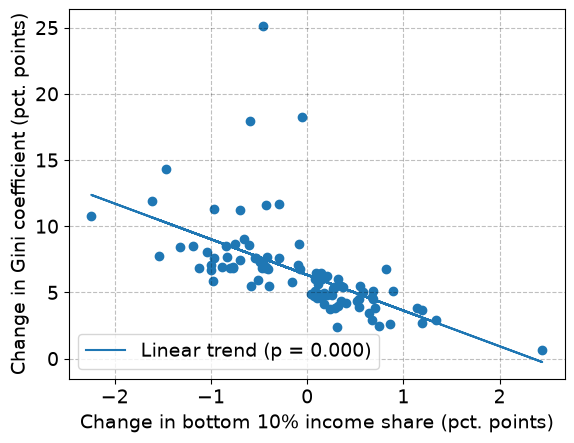

Slope: -2.694331349172473
p-value: 4.6391348399827117e-10


In [23]:
x = bottom10_change['change']
y = Gini_change['change']

slope, intercept, r, p, se = linregress(x, y)

plt.scatter(x, y)
plt.plot(x, intercept + slope*x, label=f'Linear trend (p = {p:.3f})')
plt.xlabel('Change in bottom 10% income share (pct. points)')
plt.ylabel('Change in Gini coefficient (pct. points)')
plt.legend()
plt.show()

print('Slope:', slope)
print('p-value:', p)

As expected we find a statistically significant negative relationship between the change in the bottom 10% income share and the change in the Gini coefficient. Thus, municipalities where the bottom 10% experienced the smallest increases in income share also tended to experience the largest increases in the Gini coefficient.

## 2. <a id='toc1_'></a>[Simulating the income distribution](#toc2_)

### 2.1. <a id='toc1_1_'></a>[The model](#toc2_1_)

We start by importing the necessary packages:

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

We code the life cycle model, see the file "model.py"

In [122]:
import importlib
import model
importlib.reload(model)

<module 'model' from '/Users/frejaphilbert/Desktop/Programming/projects-2025-freja-og-asta/1_dataproject/model.py'>

### 2.2. <a id='toc1_1_'></a>[Simulate the income distribution](#toc2_2_)

#### 2.2.1 <a id='toc1_1_'></a>[Control checks](#toc2_2_1_)

We start by running the simulation. In order to check that the simulation has run correctly we do the two controls listed in the assignment: 

 - First control: The education shares simulated should match the three listed education shares in the variable description. 

 - Second control: The simulated unemployment rate should converge towards the theoretical steady state value. We will do the control by plotting the unemployment rate up againt the theoretical unemployment rate, and examing the unemployment rate at three different age groups. 

In [112]:
#First control: We import the simulated shares from model.py.  
from model import education, education_shares

short_share, medium_share, long_share = education_shares(education)

print(short_share)
print(medium_share)
print(long_share)

0.39728
0.35224
0.25048


Results from the first control: The simulated shares is very similar to the theoretical shares. 

Theoretical steady-state unemployment rate: 0.07692307692307693
Age 40: 0.0809
Age 55: 0.0788
Age 60: 0.0819


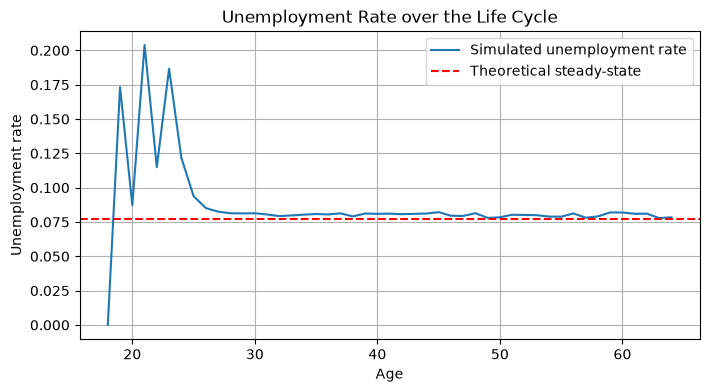

In [113]:
#Second control: The simulated unemployment rate should converge towards the theoretical steady state value. 
from model import theoretical_unemployment

print("Theoretical steady-state unemployment rate:",
      theoretical_unemployment())

from model import unemployment_at_ages

unemployment_at_ages([40, 55, 60])

from model import plot_unemployment
plot_unemployment()
plt.show()

Results from the second control: The visiual examination of the plot shows that the simulated unemployment rate converges towards the theoretical steady state value. The three unemployment rates selected for the ages of 40, 55 and 60 is also close to the theoretical unemployment rate. 

#### 2.2.2 <a id='toc1_1_'></a>[Mean and selected percentiles of income over the life cycle](#toc2_2_2_)

We have now simulated and tested the life-cycle simulation. 
Afterward we plot the the mean and specific percentiles of income over the life cycle. 

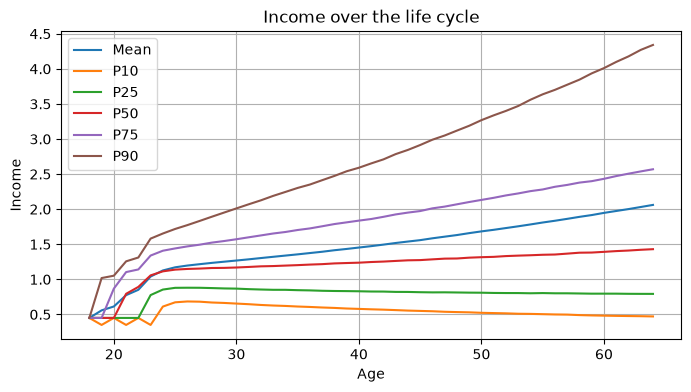

In [114]:
from model import plot_income_distribution
plot_income_distribution()
plt.show()

#### 2.2.3 <a id='toc1_1_'></a>[Histograms of the income distribution at different ages](#toc2_2_3_)

We plot a histogram of the income distribution at specific ages.

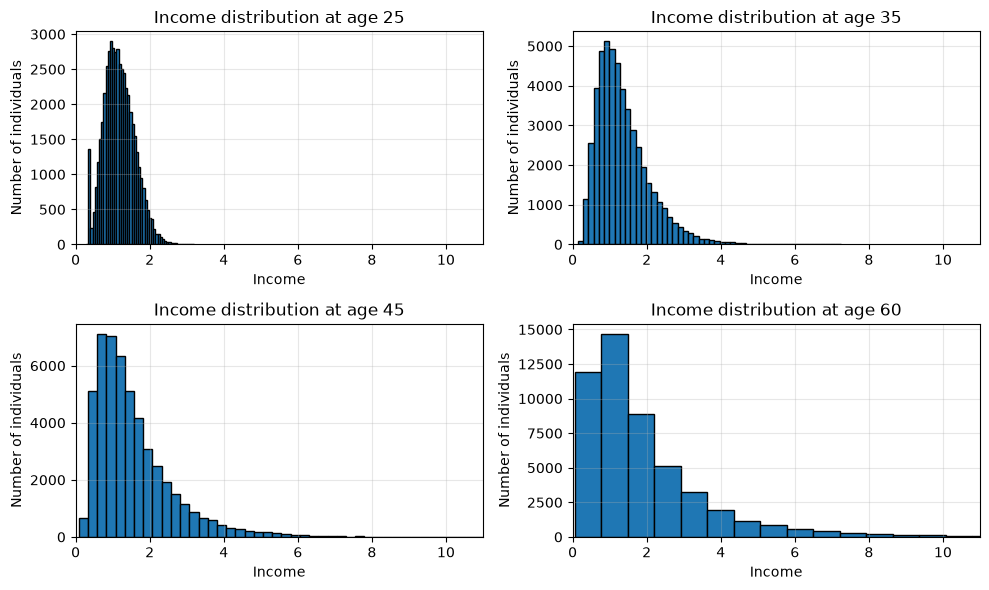

In [115]:
from model import plot_income_histograms
plot_income_histograms()
plt.show()

From the histograms it is clear that the distribution of incomes becomes more dispersed with age. This is due to the agents in the model receives the same salary, SU, during the years where they take an education. After the salaries start to differ, because some agents become employed right away and other is unemployed. The initial level of human capital also differ across the different education lenghts. The human capital accumulation also differ for individuals with different educations lenghts. The increase in human capital when an agent is employed is the rate delta. The income of the agents with the longest education also grow faster than agents with a short education. This is all reasons for why the income distribution is more equalised earlier in the life cycle. 

### 2.3. <a id='toc1_1_'></a>[Compute the Gini coefficient](#toc2_3_)

#### 2.3.1 <a id='toc1_1_'></a>[Gini coefficient and Lorenz curve for the full simulated sample](#toc2_3_1_)

We start by testing the Gini coefficient on [0,1]

In [102]:
from model import gini_uniform_test
gini_uniform_test()

Gini uniform: 0.3333366666666666


The Gini coefficient of a uniform distribution on [0, 1] is 1/3, which is equal to the above check.

In [103]:
from model import print_gini
print_gini()

Gini coefficient, full sample: 0.37210166498491803


The Gini coefficient for the full sample is 37%

Afterward we plot the lorenz curve.

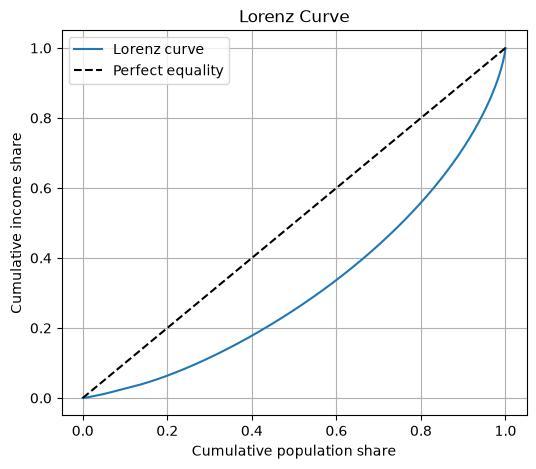

In [104]:
from model import plot_lorenz_curve
plot_lorenz_curve()
plt.show()

#### 2.3.2 <a id='toc1_1_'></a>[Compute the Gini coefficient for all ages in the model](#toc2_3_2_)

The Gini coefficient for each age:

In [105]:
from model import gini_by_age
print(gini_by_age())

Age: 18   Gini: -0.0000
Age: 19   Gini: 0.2050
Age: 20   Gini: 0.2154
Age: 21   Gini: 0.2616
Age: 22   Gini: 0.2399
Age: 23   Gini: 0.2254
Age: 24   Gini: 0.2026
Age: 25   Gini: 0.1968
Age: 26   Gini: 0.2012
Age: 27   Gini: 0.2089
Age: 28   Gini: 0.2186
Age: 29   Gini: 0.2282
Age: 30   Gini: 0.2373
Age: 31   Gini: 0.2461
Age: 32   Gini: 0.2549
Age: 33   Gini: 0.2637
Age: 34   Gini: 0.2712
Age: 35   Gini: 0.2787
Age: 36   Gini: 0.2864
Age: 37   Gini: 0.2941
Age: 38   Gini: 0.3014
Age: 39   Gini: 0.3088
Age: 40   Gini: 0.3159
Age: 41   Gini: 0.3227
Age: 42   Gini: 0.3295
Age: 43   Gini: 0.3365
Age: 44   Gini: 0.3427
Age: 45   Gini: 0.3490
Age: 46   Gini: 0.3562
Age: 47   Gini: 0.3626
Age: 48   Gini: 0.3692
Age: 49   Gini: 0.3752
Age: 50   Gini: 0.3812
Age: 51   Gini: 0.3866
Age: 52   Gini: 0.3924
Age: 53   Gini: 0.3980
Age: 54   Gini: 0.4035
Age: 55   Gini: 0.4093
Age: 56   Gini: 0.4147
Age: 57   Gini: 0.4192
Age: 58   Gini: 0.4252
Age: 59   Gini: 0.4308
Age: 60   Gini: 0.4365
Age: 61   

The Gini coefficient is printed for all ages in the model. From the values it is clear that the Gini coefficient rise with age, and when all agents in the model is younger the income is less dispersed. This is expected as the model design has different delta values for agents with different education types. Therefore the accumulation of human capital which in this model is equal to income, will be different and have effect on the income distribution. 

### 2.4. <a id='toc1_1_'></a>[What drives inequality?](#toc2_4_)

We remove the following components of the model one at a time, in order to examine which has the largest effect on Gini coefficient:
- Educational differences, 
- Shocks to human capital, 
- Depreciation of human capital while unemployed, 
- Unemployment itself.

In [106]:
from model import run_inequality_experiments

results = run_inequality_experiments()

Gini coefficients
Model                              Pooled     Age 50
Baseline                           0.3719     0.3808
No education differences           0.3275     0.3274
No human capital shocks            0.2744     0.2487
No unemployment depreciation       0.3774     0.3657
No unemployment                    0.3745     0.3643

Reduction in pooled Gini relative to baseline
No education differences       0.0444
No human capital shocks        0.0974
No unemployment depreciation   -0.0055
No unemployment                -0.0026


The Gini coefficient in the original simulation is around 37% for the entire sample and around 38% for the age 50. To identify which component of the model has the largest effect on income inequality, we have done four additional simulations removing each of the above lsited components. 

1. No educational differences: We have modelled this to mean that every individual in the model has the medium education lenght. The result could change by choosing either the short or long education lenght. The Gini coefficient for the entire sample is around 4.5% smaller and 5.3% smaller for the 50 year age group. This means that the Gini coefficient does not rise as much with age as in the original simulation, if every agent was assigned the same initial human capital and had the same human capital accumulation over time. 

2. No human capital shocks: The no human capital shocks is done by setting ψ = 1. These shocks represent unpredictable changes to human capital for each agent. When excluding them from the simulation the Gini coefficient for the entire sample is around 27%, and around 25% for the 50 year age group. This result shows that removing these shocks has large effects on the Gini coefficint, as it is around 10% smaller than in the original simulation. This mechanishm matters the most in terms of income ineqaulity measured by the Gini coefficient. 

3. No unemployment depreciation: This is modeled by setting δ = 0. This means that when unemployed, the human capital at the point of becoming unemployed is kept constant. The Gini coefficient is almost equal to the one from the original simulation, around 0.6% larger. However the Gini coefficient for the 50 year age group is smaller than in the original simualtion. This means that the differences in the accumulation of income over time happens slower.

4. No unemployment: This is modeled by skipping the job-finding and job-separation process, as all agents in the model is either in education or employed. This has no to little impact on the Gini coeffcient for the entire sample, it is around 0.3% larger than in the original simulation. However, the Gini coefficient for the 50 year age group is smaller than in the original simulation. 

### 2.5. <a id='toc1_1_'></a>[Extension: more risk](#toc2_5_)

We have added a component of an exponential probability of severe illness that rises with age. It is an exponential function that begins with the probability of 0.1% at age 18 and ends with a probability of around 6.5% at age 64. If a person becomes ill, then they become unemployed, for that period. The severe illnes is randomly assigned, and if an agent becomes ill in that year they will lose 10% human capital in the year of illness.

This is included in the model as another risk, and is compared to the original simulation.

In [123]:
from model import (
    income_baseline,
    income_illness,
    mean_baseline,
    mean_illness,
    gini_baseline_by_age,
    gini_illness_by_age,
    illness_probability_by_age
)

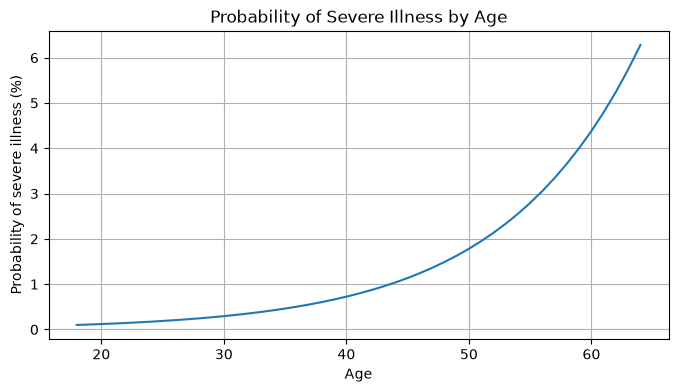

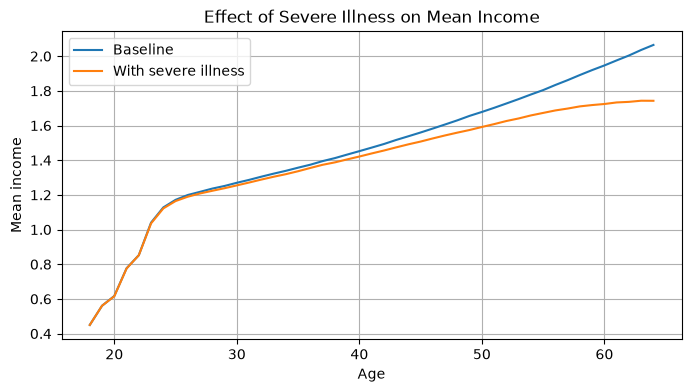

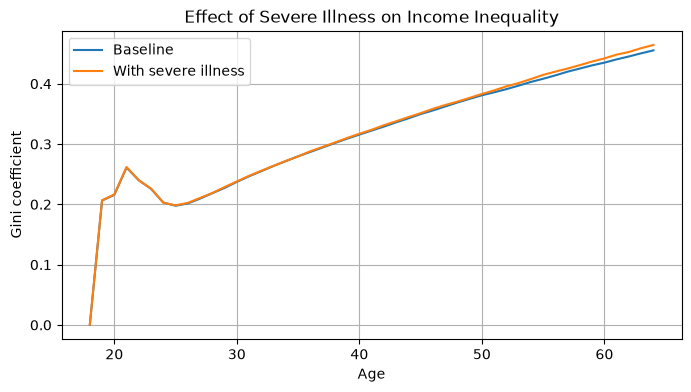

In [124]:
from model import (
    plot_illness_income,
    plot_illness_gini,
    plot_illness_probability
)

plot_illness_probability()
plot_illness_income()
plot_illness_gini()

As the figures show, the mean income over time has a large difference for the elder agents. However, the Gini coefficient is almost unchanged. 